# Financial Returns Prediction with XGBoost

This notebook uses **XGBoost** (gradient boosting) to predict financial returns using:

1. **Baseline model**: Only macro control variables and lagged returns
2. **EPI model**: Add Emotion Polarity Index
3. **EPI Weighted model**: Add topic-weighted EPI
4. **Extended EPI model**: Include lagged EPI, asymmetric effects, and combined features

We compare XGBoost performance against the ARX/VAR models from the previous notebooks using:
- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)  
- Directional Accuracy (% correct direction predictions)

> **Note:** XGBoost is a non-linear model that can capture complex interactions between features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Display and plotting options
pd.options.display.float_format = "{:.4f}".format
plt.rcParams["figure.figsize"] = (10, 4)

DATA_DIR = "./data/"
OUTPUT_DIR = "./data/"

RAW_FINANCIAL_FILE = DATA_DIR + "market_data.json"
EPI_FILE = DATA_DIR + "epi_data.json"

# Analysis window
START_DATE = "2025-01-01"
END_DATE = "2025-05-31"

## 1. Load and Prepare Data

Load the financial data and EPI indices, then construct returns and control variables.

In [2]:
# --- Load raw financial data ---
try:
    df_raw = pd.read_json(RAW_FINANCIAL_FILE)
except ValueError:
    df_raw = pd.read_csv(RAW_FINANCIAL_FILE)

# Parse dates and sort
if "Date_" in df_raw.columns:
    df_raw["Date_"] = pd.to_datetime(df_raw["Date_"])
    df_raw = df_raw.sort_values("Date_").set_index("Date_")
else:
    raise KeyError("Expected a 'Date_' column.")

print(f"Loaded {len(df_raw)} rows of financial data")
print(f"Date range: {df_raw.index.min()} to {df_raw.index.max()}")

Loaded 367 rows of financial data
Date range: 2024-11-18 00:00:00 to 2025-11-19 00:00:00


In [3]:
# Rename columns to simpler names
rename_map = {
    "Close_BTC-USD": "close_btc",
    "Close_GC=F": "close_gold",
    "Close_CL=F": "close_oil",
    "Close_^GSPC": "close_spx",
    "Close_CNY=X": "close_usdcny",
    "Close_EUR=X": "close_eurusd",
    "Close_^TNX": "close_ust10y",
    "Volume_BTC-USD": "vol_btc",
    "Volume_GC=F": "vol_gold",
    "Volume_^GSPC": "vol_spx",
}

df = df_raw.rename(columns=rename_map)

# Create business day index and forward-fill prices
full_index = pd.date_range(df.index.min(), df.index.max(), freq="B")
df = df.reindex(full_index)

price_cols = [c for c in df.columns if c.startswith("close_")]
df[price_cols] = df[price_cols].ffill()

print("Data prepared with forward-filled prices")

Data prepared with forward-filled prices


In [4]:
# Construct returns and control variables
def log_return(series):
    return np.log(series).diff()

returns = pd.DataFrame(index=df.index)

# Asset returns (target variables)
returns["r_btc"] = log_return(df["close_btc"])
returns["r_gold"] = log_return(df["close_gold"])
returns["r_spx"] = log_return(df["close_spx"])

# Control variables (features)
returns["dln_eurusd"] = log_return(df["close_eurusd"])
returns["dln_usdcny"] = log_return(df["close_usdcny"])
returns["dln_oil"] = log_return(df["close_oil"])
returns["dy10"] = df["close_ust10y"].diff()

# Drop initial NaNs and restrict to analysis window
returns = returns.dropna()
returns = returns.loc[START_DATE:END_DATE]

print(f"Returns data shape: {returns.shape}")
print(f"Date range: {returns.index.min()} to {returns.index.max()}")

Returns data shape: (108, 7)
Date range: 2025-01-01 00:00:00 to 2025-05-30 00:00:00


In [5]:
# Load and merge EPI data
df_epi = pd.read_json(EPI_FILE)
df_epi['date'] = pd.to_datetime(df_epi['date'])
df_epi = df_epi.set_index('date')

# Get EPI columns
epi_cols = [col for col in df_epi.columns if col.startswith('epi') or col in ['ei_creator', 'ei_community']]

# Merge on index (date)
returns = returns.join(df_epi[epi_cols], how='left')
returns[epi_cols] = returns[epi_cols].fillna(0)

print(f"\nEPI data merged. Columns: {returns.columns.tolist()}")
print(f"Shape: {returns.shape}")


EPI data merged. Columns: ['r_btc', 'r_gold', 'r_spx', 'dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10', 'ei_creator', 'ei_community', 'epi', 'epi_weighted', 'epi_', 'epi_Environmental and Infrastructure', 'epi_Labor and Workforce', 'epi_Health and Social Welfare', 'epi_Legal and Regulatory Framework', 'epi_Education and Knowledge', 'epi_Psychological and Emotional Aspects', 'epi_Leadership and Governance', 'epi_Economic and Financial Matters', 'epi_Disaster and Resilience', 'epi_Security and Conflict', 'epi_Disputes and Opinions', 'epi_Miscellaneous and Other', 'epi_Sports and Recreation', 'epi_Power and Influence Dynamics', 'epi_Social and Cultural Aspects', 'epi_Quality of Life and Standards', 'epi_Trust, Credibility, and Communication', 'epi_Conspiracy and Historical Events']
Shape: (108, 30)


## 2. Feature Engineering

Create lagged features for returns and EPI variables.

In [6]:
# Create lagged features
max_lag = 5
data = returns.copy()

# Create lagged returns for each asset
for asset in ["r_btc", "r_gold", "r_spx"]:
    for lag in range(1, max_lag + 1):
        data[f"{asset}_l{lag}"] = data[asset].shift(lag)

# Create lagged EPI variables
for lag in range(1, max_lag + 1):
    data[f'epi_l{lag}'] = data['epi'].shift(lag)
    data[f'epi_weighted_l{lag}'] = data['epi_weighted'].shift(lag)

# Create asymmetric EPI variables
data['epi_pos'] = np.maximum(data['epi'], 0)
data['epi_neg'] = np.minimum(data['epi'], 0)
data['epi_weighted_pos'] = np.maximum(data['epi_weighted'], 0)
data['epi_weighted_neg'] = np.minimum(data['epi_weighted'], 0)

# Create rolling statistics for EPI
data['epi_ma5'] = data['epi'].rolling(5).mean()
data['epi_std5'] = data['epi'].rolling(5).std()
data['epi_weighted_ma5'] = data['epi_weighted'].rolling(5).mean()
data['epi_weighted_std5'] = data['epi_weighted'].rolling(5).std()

# Create volatility features
for asset in ["r_btc", "r_gold", "r_spx"]:
    data[f"{asset}_vol5"] = data[asset].rolling(5).std()

# Drop NaN rows
data = data.dropna()

print(f"Feature-engineered data shape: {data.shape}")
print(f"Number of observations: {len(data)}")
print(f"\nFeature columns: {[c for c in data.columns if c not in ['r_btc', 'r_gold', 'r_spx']]}")

Feature-engineered data shape: (103, 66)
Number of observations: 103

Feature columns: ['dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10', 'ei_creator', 'ei_community', 'epi', 'epi_weighted', 'epi_', 'epi_Environmental and Infrastructure', 'epi_Labor and Workforce', 'epi_Health and Social Welfare', 'epi_Legal and Regulatory Framework', 'epi_Education and Knowledge', 'epi_Psychological and Emotional Aspects', 'epi_Leadership and Governance', 'epi_Economic and Financial Matters', 'epi_Disaster and Resilience', 'epi_Security and Conflict', 'epi_Disputes and Opinions', 'epi_Miscellaneous and Other', 'epi_Sports and Recreation', 'epi_Power and Influence Dynamics', 'epi_Social and Cultural Aspects', 'epi_Quality of Life and Standards', 'epi_Trust, Credibility, and Communication', 'epi_Conspiracy and Historical Events', 'r_btc_l1', 'r_btc_l2', 'r_btc_l3', 'r_btc_l4', 'r_btc_l5', 'r_gold_l1', 'r_gold_l2', 'r_gold_l3', 'r_gold_l4', 'r_gold_l5', 'r_spx_l1', 'r_spx_l2', 'r_spx_l3', 'r_spx_l4', 'r_spx

## 3. Define Feature Sets

Define different feature sets for model comparison:
- **Baseline**: Only control variables and lagged returns
- **+ EPI**: Add contemporaneous EPI
- **+ EPI Weighted**: Add topic-weighted EPI
- **+ EPI Lagged**: Add lagged EPI (t-1 to t-5)
- **+ EPI Full**: All EPI features (lagged, asymmetric, rolling stats)

In [7]:
# Define control columns
control_cols = ["dln_eurusd", "dln_usdcny", "dln_oil", "dy10"]

# Define feature sets for each model specification
def get_feature_cols(asset, model_type="baseline"):
    """
    Get feature columns for a given asset and model type.
    
    Model types:
    - baseline: lagged returns + controls
    - epi: baseline + contemporaneous EPI
    - epi_weighted: baseline + contemporaneous EPI weighted
    - epi_lagged: baseline + lagged EPI (t-1 to t-5)
    - epi_asymmetric: baseline + asymmetric EPI (pos/neg)
    - epi_full: all EPI features
    """
    # Base features: lagged returns for the target asset
    lag_cols = [f"{asset}_l{lag}" for lag in range(1, 4)]  # Use 3 lags
    
    # Cross-asset lagged returns (information from other markets)
    other_assets = [a for a in ["r_btc", "r_gold", "r_spx"] if a != asset]
    cross_cols = [f"{a}_l1" for a in other_assets]  # Only lag-1 for other assets
    
    # Volatility features
    vol_cols = [f"{asset}_vol5"]
    
    base_features = lag_cols + cross_cols + control_cols + vol_cols
    
    if model_type == "baseline":
        return base_features
    
    elif model_type == "epi":
        return base_features + ["epi"]
    
    elif model_type == "epi_weighted":
        return base_features + ["epi_weighted"]
    
    elif model_type == "epi_lagged":
        epi_lags = [f"epi_l{lag}" for lag in range(1, 4)]  # Lags 1-3
        return base_features + epi_lags
    
    elif model_type == "epi_asymmetric":
        return base_features + ["epi_pos", "epi_neg"]
    
    elif model_type == "epi_full":
        epi_lags = [f"epi_l{lag}" for lag in range(1, 4)]
        epi_rolling = ["epi_ma5", "epi_std5"]
        return base_features + ["epi", "epi_pos", "epi_neg"] + epi_lags + epi_rolling
    
    elif model_type == "epi_weighted_full":
        epi_lags = [f"epi_weighted_l{lag}" for lag in range(1, 4)]
        epi_rolling = ["epi_weighted_ma5", "epi_weighted_std5"]
        return base_features + ["epi_weighted", "epi_weighted_pos", "epi_weighted_neg"] + epi_lags + epi_rolling
    
    else:
        raise ValueError(f"Unknown model type: {model_type}")

# Show example feature sets
print("Feature sets for r_btc:")
for mtype in ["baseline", "epi", "epi_weighted", "epi_lagged", "epi_asymmetric", "epi_full"]:
    cols = get_feature_cols("r_btc", mtype)
    print(f"\n{mtype}: {len(cols)} features")
    print(f"  {cols}")

Feature sets for r_btc:

baseline: 10 features
  ['r_btc_l1', 'r_btc_l2', 'r_btc_l3', 'r_gold_l1', 'r_spx_l1', 'dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10', 'r_btc_vol5']

epi: 11 features
  ['r_btc_l1', 'r_btc_l2', 'r_btc_l3', 'r_gold_l1', 'r_spx_l1', 'dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10', 'r_btc_vol5', 'epi']

epi_weighted: 11 features
  ['r_btc_l1', 'r_btc_l2', 'r_btc_l3', 'r_gold_l1', 'r_spx_l1', 'dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10', 'r_btc_vol5', 'epi_weighted']

epi_lagged: 13 features
  ['r_btc_l1', 'r_btc_l2', 'r_btc_l3', 'r_gold_l1', 'r_spx_l1', 'dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10', 'r_btc_vol5', 'epi_l1', 'epi_l2', 'epi_l3']

epi_asymmetric: 12 features
  ['r_btc_l1', 'r_btc_l2', 'r_btc_l3', 'r_gold_l1', 'r_spx_l1', 'dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10', 'r_btc_vol5', 'epi_pos', 'epi_neg']

epi_full: 18 features
  ['r_btc_l1', 'r_btc_l2', 'r_btc_l3', 'r_gold_l1', 'r_spx_l1', 'dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10', 'r_btc_vol5', 'epi',

## 4. XGBoost Model Training Functions

Define functions for training XGBoost models with:
- Rolling window cross-validation (time series aware)
- Hyperparameter tuning
- Evaluation metrics (RMSE, MAE, Directional Accuracy)

In [8]:
def train_xgboost_rolling(data, asset, feature_cols, min_train=60, 
                          n_estimators=100, max_depth=3, learning_rate=0.1,
                          scale_features=True):
    """
    Train XGBoost with rolling window forecasts (expanding window).
    
    Returns:
        dict: Results including RMSE, MAE, directional accuracy, and predictions
    """
    # Prepare data
    df_fit = data.dropna(subset=[asset] + feature_cols)
    
    if len(df_fit) <= min_train:
        return {"error": "Insufficient data"}
    
    y = df_fit[asset].values
    X = df_fit[feature_cols].values
    dates = df_fit.index
    
    # Initialize scaler if needed
    scaler = StandardScaler() if scale_features else None
    
    # Rolling predictions
    preds, actuals, pred_dates = [], [], []
    
    for i in range(min_train, len(df_fit)):
        # Training data (expanding window)
        X_train, y_train = X[:i], y[:i]
        X_test = X[i:i+1]
        
        # Scale features
        if scale_features:
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
        else:
            X_train_scaled, X_test_scaled = X_train, X_test
        
        # Train XGBoost
        model = XGBRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            random_state=42,
            verbosity=0,
            n_jobs=-1
        )
        model.fit(X_train_scaled, y_train)
        
        # Predict
        pred = model.predict(X_test_scaled)[0]
        
        preds.append(pred)
        actuals.append(y[i])
        pred_dates.append(dates[i])
    
    # Convert to arrays
    preds = np.array(preds)
    actuals = np.array(actuals)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae = mean_absolute_error(actuals, preds)
    
    # Directional accuracy
    dir_correct = np.sign(preds) == np.sign(actuals)
    dir_acc = np.mean(dir_correct) * 100
    
    return {
        "rmse": rmse,
        "mae": mae,
        "dir_acc": dir_acc,
        "n_predictions": len(preds),
        "predictions": pd.Series(preds, index=pred_dates),
        "actuals": pd.Series(actuals, index=pred_dates)
    }

In [9]:
def train_xgboost_with_tuning(data, asset, feature_cols, min_train=60, n_splits=3):
    """
    Train XGBoost with hyperparameter tuning using TimeSeriesSplit.
    
    Returns:
        dict: Results including best parameters and performance metrics
    """
    # Prepare data
    df_fit = data.dropna(subset=[asset] + feature_cols)
    
    if len(df_fit) <= min_train:
        return {"error": "Insufficient data"}
    
    y = df_fit[asset].values
    X = df_fit[feature_cols].values
    dates = df_fit.index
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Define parameter grid
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [2, 3, 4],
        'learning_rate': [0.05, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    }
    
    # Time series cross-validation
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    # Grid search
    model = XGBRegressor(random_state=42, verbosity=0, n_jobs=-1)
    
    grid_search = GridSearchCV(
        model, 
        param_grid, 
        cv=tscv, 
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=0
    )
    
    # Fit on training portion
    train_size = int(len(X_scaled) * 0.8)
    grid_search.fit(X_scaled[:train_size], y[:train_size])
    
    best_params = grid_search.best_params_
    
    # Now do rolling forecasts with best parameters
    result = train_xgboost_rolling(
        data, asset, feature_cols, min_train,
        n_estimators=best_params['n_estimators'],
        max_depth=best_params['max_depth'],
        learning_rate=best_params['learning_rate']
    )
    
    result['best_params'] = best_params
    result['cv_score'] = -grid_search.best_score_  # Convert back to positive MSE
    
    return result

## 5. Train Baseline XGBoost Models

Train XGBoost models without EPI features to establish a baseline.

In [10]:
# Train baseline XGBoost for each asset
print("=" * 70)
print("BASELINE XGBOOST MODELS (No EPI)")
print("=" * 70)

assets = ["r_btc", "r_gold", "r_spx"]
baseline_results = {}

for asset in assets:
    feature_cols = get_feature_cols(asset, "baseline")
    print(f"\nTraining {asset} with {len(feature_cols)} features...")
    
    result = train_xgboost_rolling(data, asset, feature_cols)
    baseline_results[asset] = result
    
    if "error" not in result:
        print(f"  RMSE: {result['rmse']:.5f}")
        print(f"  MAE: {result['mae']:.5f}")
        print(f"  Directional Accuracy: {result['dir_acc']:.2f}%")
        print(f"  N predictions: {result['n_predictions']}")
    else:
        print(f"  Error: {result['error']}")

BASELINE XGBOOST MODELS (No EPI)

Training r_btc with 10 features...
  RMSE: 0.02843
  MAE: 0.02177
  Directional Accuracy: 51.16%
  N predictions: 43

Training r_gold with 10 features...
  RMSE: 0.02235
  MAE: 0.01803
  Directional Accuracy: 41.86%
  N predictions: 43

Training r_spx with 10 features...
  RMSE: 0.02426
  MAE: 0.01606
  Directional Accuracy: 39.53%
  N predictions: 43


## 6. Train XGBoost Models with EPI Features

Train models with different EPI feature configurations.

In [11]:
# Train XGBoost with different EPI configurations
print("=" * 70)
print("XGBOOST MODELS WITH EPI FEATURES")
print("=" * 70)

model_types = ["epi", "epi_weighted", "epi_lagged", "epi_asymmetric", "epi_full", "epi_weighted_full"]
all_results = {}

for model_type in model_types:
    print(f"\n{'='*50}")
    print(f"Model: {model_type}")
    print(f"{'='*50}")
    
    all_results[model_type] = {}
    
    for asset in assets:
        feature_cols = get_feature_cols(asset, model_type)
        print(f"\n{asset}: {len(feature_cols)} features")
        
        result = train_xgboost_rolling(data, asset, feature_cols)
        all_results[model_type][asset] = result
        
        if "error" not in result:
            print(f"  RMSE: {result['rmse']:.5f}")
            print(f"  Dir Acc: {result['dir_acc']:.2f}%")
        else:
            print(f"  Error: {result['error']}")

XGBOOST MODELS WITH EPI FEATURES

Model: epi

r_btc: 11 features
  RMSE: 0.02857
  Dir Acc: 51.16%

r_gold: 11 features
  RMSE: 0.02256
  Dir Acc: 44.19%

r_spx: 11 features
  RMSE: 0.02467
  Dir Acc: 41.86%

Model: epi_weighted

r_btc: 11 features
  RMSE: 0.02988
  Dir Acc: 53.49%

r_gold: 11 features
  RMSE: 0.02272
  Dir Acc: 41.86%

r_spx: 11 features
  RMSE: 0.02403
  Dir Acc: 41.86%

Model: epi_lagged

r_btc: 13 features
  RMSE: 0.03005
  Dir Acc: 44.19%

r_gold: 13 features
  RMSE: 0.02272
  Dir Acc: 37.21%

r_spx: 13 features
  RMSE: 0.02412
  Dir Acc: 41.86%

Model: epi_asymmetric

r_btc: 12 features
  RMSE: 0.02857
  Dir Acc: 51.16%

r_gold: 12 features
  RMSE: 0.02256
  Dir Acc: 44.19%

r_spx: 12 features
  RMSE: 0.02467
  Dir Acc: 41.86%

Model: epi_full

r_btc: 18 features
  RMSE: 0.03050
  Dir Acc: 34.88%

r_gold: 18 features
  RMSE: 0.02217
  Dir Acc: 37.21%

r_spx: 18 features
  RMSE: 0.02262
  Dir Acc: 51.16%

Model: epi_weighted_full

r_btc: 18 features
  RMSE: 0.0288

## 7. Model Comparison Summary

Compare all XGBoost model configurations.

In [12]:
# Create comparison dataframe
comparison_data = []

# Add baseline results
for asset in assets:
    result = baseline_results[asset]
    if "error" not in result:
        comparison_data.append({
            "Model": "Baseline",
            "Asset": asset,
            "RMSE": result["rmse"],
            "MAE": result["mae"],
            "Dir Acc (%)": result["dir_acc"]
        })

# Add EPI model results
for model_type in model_types:
    for asset in assets:
        result = all_results[model_type][asset]
        if "error" not in result:
            comparison_data.append({
                "Model": f"+ {model_type}",
                "Asset": asset,
                "RMSE": result["rmse"],
                "MAE": result["mae"],
                "Dir Acc (%)": result["dir_acc"]
            })

comparison_df = pd.DataFrame(comparison_data)

print("=" * 70)
print("XGBOOST MODEL COMPARISON SUMMARY")
print("=" * 70)

# RMSE comparison
print("\n📊 RMSE Comparison (lower is better):")
rmse_pivot = comparison_df.pivot(index="Model", columns="Asset", values="RMSE").round(5)
display(rmse_pivot)

# Directional Accuracy comparison
print("\n🎯 Directional Accuracy Comparison (%, higher is better):")
dir_pivot = comparison_df.pivot(index="Model", columns="Asset", values="Dir Acc (%)").round(2)
display(dir_pivot)

XGBOOST MODEL COMPARISON SUMMARY

📊 RMSE Comparison (lower is better):


Asset,r_btc,r_gold,r_spx
Model,,,
+ epi,0.0286,0.0226,0.0247
+ epi_asymmetric,0.0286,0.0226,0.0247
+ epi_full,0.0305,0.0222,0.0226
+ epi_lagged,0.0301,0.0227,0.0241
+ epi_weighted,0.0299,0.0227,0.0240
+ epi_weighted_full,0.0288,0.0225,0.0244
Baseline,0.0284,0.0223,0.0243



🎯 Directional Accuracy Comparison (%, higher is better):


Asset,r_btc,r_gold,r_spx
Model,,,
+ epi,51.1600,44.1900,41.8600
+ epi_asymmetric,51.1600,44.1900,41.8600
+ epi_full,34.8800,37.2100,51.1600
+ epi_lagged,44.1900,37.2100,41.8600
+ epi_weighted,53.4900,41.8600,41.8600
+ epi_weighted_full,46.5100,46.5100,46.5100
Baseline,51.1600,41.8600,39.5300


In [13]:
# Calculate improvement over baseline
print("=" * 70)
print("IMPROVEMENT OVER BASELINE")
print("=" * 70)

improvement_data = []

for asset in assets:
    baseline_rmse = baseline_results[asset]["rmse"]
    baseline_dir = baseline_results[asset]["dir_acc"]
    
    for model_type in model_types:
        result = all_results[model_type][asset]
        if "error" not in result:
            rmse_imp = (baseline_rmse - result["rmse"]) / baseline_rmse * 100
            dir_imp = result["dir_acc"] - baseline_dir
            
            improvement_data.append({
                "Model": f"+ {model_type}",
                "Asset": asset,
                "RMSE Improvement (%)": rmse_imp,
                "Dir Acc Improvement (pp)": dir_imp
            })

improvement_df = pd.DataFrame(improvement_data)

print("\nRMSE Improvement over Baseline (%, positive = better):")
display(improvement_df.pivot(index="Model", columns="Asset", values="RMSE Improvement (%)").round(2))

print("\nDirectional Accuracy Improvement (percentage points):")
display(improvement_df.pivot(index="Model", columns="Asset", values="Dir Acc Improvement (pp)").round(2))

IMPROVEMENT OVER BASELINE

RMSE Improvement over Baseline (%, positive = better):


Asset,r_btc,r_gold,r_spx
Model,,,
+ epi,-0.5000,-0.9500,-1.6900
+ epi_asymmetric,-0.5000,-0.9500,-1.6900
+ epi_full,-7.3100,0.8000,6.7800
+ epi_lagged,-5.7300,-1.6500,0.5900
+ epi_weighted,-5.1200,-1.6500,0.9600
+ epi_weighted_full,-1.3600,-0.8400,-0.4700



Directional Accuracy Improvement (percentage points):


Asset,r_btc,r_gold,r_spx
Model,,,
+ epi,0.0000,2.3300,2.3300
+ epi_asymmetric,0.0000,2.3300,2.3300
+ epi_full,-16.2800,-4.6500,11.6300
+ epi_lagged,-6.9800,-4.6500,2.3300
+ epi_weighted,2.3300,0.0000,2.3300
+ epi_weighted_full,-4.6500,4.6500,6.9800


## 8. Hyperparameter Tuning

Find optimal hyperparameters for the best-performing model configuration.

In [14]:
# Find best model type by average RMSE improvement
avg_improvement = improvement_df.groupby("Model")["RMSE Improvement (%)"].mean()
best_model_type = avg_improvement.idxmax().replace("+ ", "")

print(f"Best model type by avg RMSE improvement: {best_model_type}")
print(f"\nRunning hyperparameter tuning for {best_model_type}...")
print("(This may take a few minutes)\n")

tuned_results = {}

for asset in assets:
    print(f"Tuning {asset}...")
    feature_cols = get_feature_cols(asset, best_model_type)
    
    result = train_xgboost_with_tuning(data, asset, feature_cols, n_splits=3)
    tuned_results[asset] = result
    
    if "error" not in result:
        print(f"  Best params: {result['best_params']}")
        print(f"  RMSE: {result['rmse']:.5f}")
        print(f"  Dir Acc: {result['dir_acc']:.2f}%")
    else:
        print(f"  Error: {result['error']}")

Best model type by avg RMSE improvement: epi_full

Running hyperparameter tuning for epi_full...
(This may take a few minutes)

Tuning r_btc...
  Best params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 50, 'subsample': 1.0}
  RMSE: 0.03047
  Dir Acc: 46.51%
Tuning r_gold...
  Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
  RMSE: 0.02122
  Dir Acc: 37.21%
Tuning r_spx...
  Best params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200, 'subsample': 0.8}
  RMSE: 0.02303
  Dir Acc: 39.53%


In [15]:
# Compare tuned vs default parameters
print("=" * 70)
print("TUNED VS DEFAULT PARAMETERS")
print("=" * 70)

comparison_tuned = []

for asset in assets:
    default_result = all_results[best_model_type][asset]
    tuned_result = tuned_results[asset]
    
    if "error" not in default_result and "error" not in tuned_result:
        comparison_tuned.append({
            "Asset": asset,
            "Default RMSE": default_result["rmse"],
            "Tuned RMSE": tuned_result["rmse"],
            "RMSE Improvement (%)": (default_result["rmse"] - tuned_result["rmse"]) / default_result["rmse"] * 100,
            "Default Dir Acc": default_result["dir_acc"],
            "Tuned Dir Acc": tuned_result["dir_acc"]
        })

display(pd.DataFrame(comparison_tuned).round(4))

TUNED VS DEFAULT PARAMETERS


,Asset,Default RMSE,Tuned RMSE,RMSE Improvement (%),Default Dir Acc,Tuned Dir Acc
0,r_btc,0.0305,0.0305,0.0996,34.8837,46.5116
1,r_gold,0.0222,0.0212,4.3091,37.2093,37.2093
2,r_spx,0.0226,0.0230,-1.8275,51.1628,39.5349


## 9. Feature Importance Analysis

Analyze which features are most important for predictions.

FEATURE IMPORTANCE ANALYSIS

r_btc: EPI features contribute 36.2% of total importance

r_gold: EPI features contribute 24.4% of total importance

r_spx: EPI features contribute 26.5% of total importance


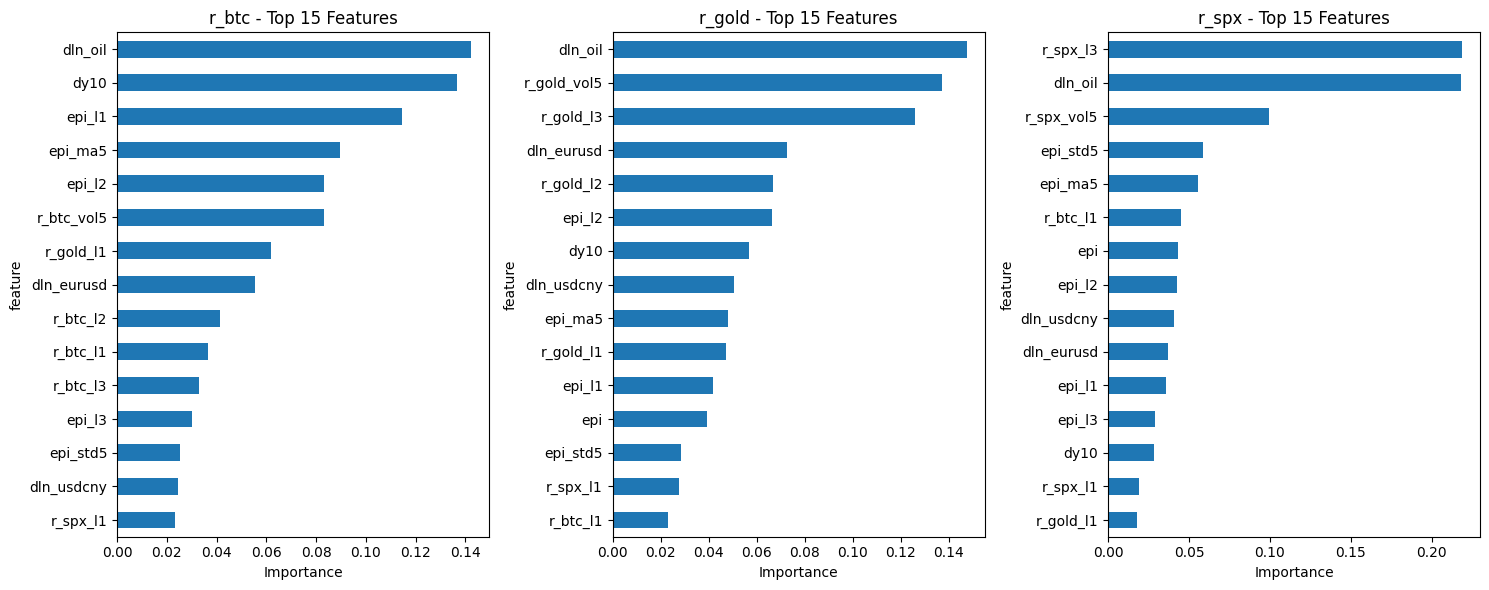

In [16]:
# Train full model on all data to get feature importance
print("=" * 70)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 70)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for idx, asset in enumerate(assets):
    feature_cols = get_feature_cols(asset, "epi_full")
    
    # Prepare data
    df_fit = data.dropna(subset=[asset] + feature_cols)
    y = df_fit[asset].values
    X = df_fit[feature_cols].values
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Train model
    model = XGBRegressor(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42,
        verbosity=0
    )
    model.fit(X_scaled, y)
    
    # Get feature importance
    importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=True)
    
    # Plot top 15 features
    ax = axes[idx]
    importance.tail(15).plot(kind='barh', x='feature', y='importance', ax=ax, legend=False)
    ax.set_title(f"{asset} - Top 15 Features")
    ax.set_xlabel("Importance")
    
    # Highlight EPI features
    epi_importance = importance[importance['feature'].str.contains('epi')]['importance'].sum()
    total_importance = importance['importance'].sum()
    print(f"\n{asset}: EPI features contribute {epi_importance/total_importance*100:.1f}% of total importance")

plt.tight_layout()
plt.show()

## 10. Visualization: Predictions vs Actuals

PREDICTIONS VS ACTUALS


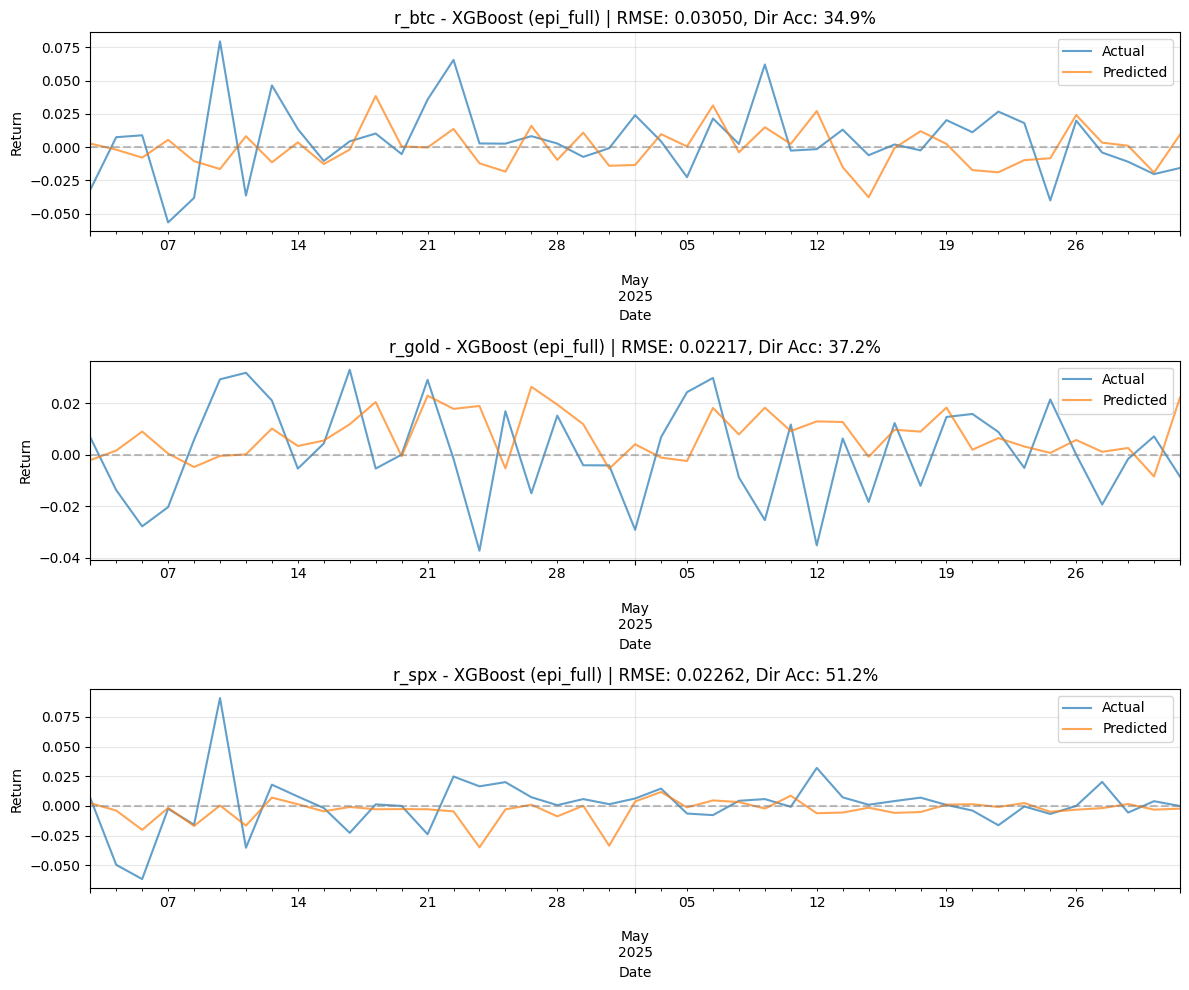

In [17]:
# Plot predictions vs actuals for the best model
print("=" * 70)
print("PREDICTIONS VS ACTUALS")
print("=" * 70)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

for idx, asset in enumerate(assets):
    result = all_results[best_model_type][asset]
    
    if "error" not in result:
        ax = axes[idx]
        
        # Plot actual vs predicted
        result['actuals'].plot(ax=ax, label='Actual', alpha=0.7)
        result['predictions'].plot(ax=ax, label='Predicted', alpha=0.7)
        
        ax.set_title(f"{asset} - XGBoost ({best_model_type}) | RMSE: {result['rmse']:.5f}, Dir Acc: {result['dir_acc']:.1f}%")
        ax.set_xlabel('Date')
        ax.set_ylabel('Return')
        ax.legend()
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

CUMULATIVE RETURNS: STRATEGY VS BUY-AND-HOLD
r_btc: Buy & Hold = 20.22%, Strategy = -14.77%
r_gold: Buy & Hold = 4.68%, Strategy = -9.77%
r_spx: Buy & Hold = 3.85%, Strategy = 25.87%


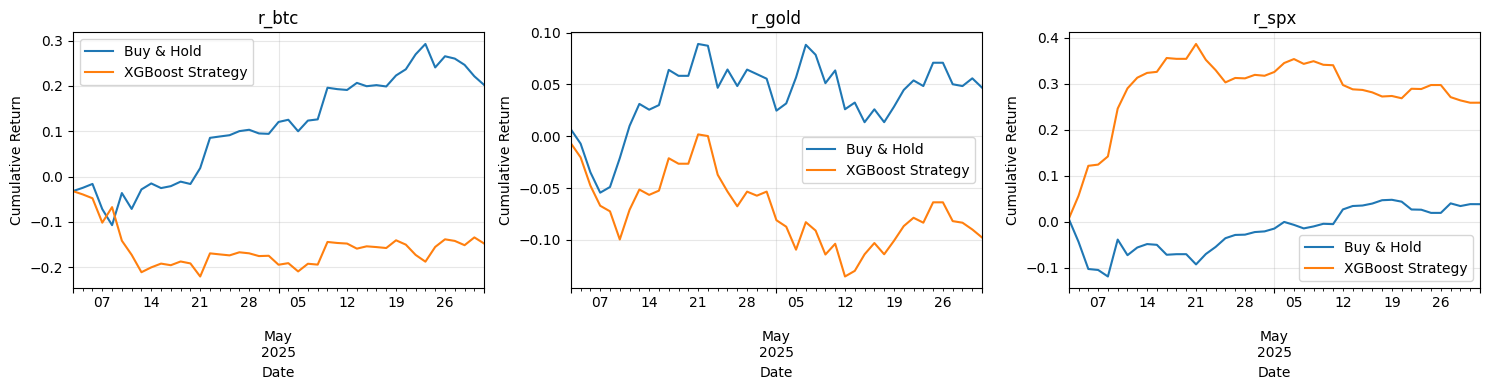

In [18]:
# Plot cumulative returns: strategy vs buy-and-hold
print("=" * 70)
print("CUMULATIVE RETURNS: STRATEGY VS BUY-AND-HOLD")
print("=" * 70)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, asset in enumerate(assets):
    result = all_results[best_model_type][asset]
    
    if "error" not in result:
        ax = axes[idx]
        
        actuals = result['actuals']
        predictions = result['predictions']
        
        # Strategy returns: go long if predicted > 0, else stay out (0 return)
        strategy_returns = actuals * np.sign(predictions)
        
        # Cumulative returns
        cum_actual = (1 + actuals).cumprod() - 1
        cum_strategy = (1 + strategy_returns).cumprod() - 1
        
        cum_actual.plot(ax=ax, label='Buy & Hold')
        cum_strategy.plot(ax=ax, label='XGBoost Strategy')
        
        ax.set_title(f"{asset}")
        ax.set_xlabel('Date')
        ax.set_ylabel('Cumulative Return')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Print final returns
        print(f"{asset}: Buy & Hold = {cum_actual.iloc[-1]*100:.2f}%, Strategy = {cum_strategy.iloc[-1]*100:.2f}%")

plt.tight_layout()
plt.show()

## 11. Final Summary & Conclusions

In [19]:
# Final summary table
print("=" * 80)
print("🏆 FINAL XGBOOST MODEL SUMMARY")
print("=" * 80)

# Best model for each asset
print("\nBest Model Configuration for Each Asset:")
print("-" * 60)

for asset in assets:
    # Find best by RMSE
    best_rmse_model = "Baseline"
    best_rmse = baseline_results[asset]["rmse"]
    
    for model_type in model_types:
        result = all_results[model_type][asset]
        if "error" not in result and result["rmse"] < best_rmse:
            best_rmse = result["rmse"]
            best_rmse_model = model_type
    
    # Find best by Dir Acc
    best_dir_model = "Baseline"
    best_dir = baseline_results[asset]["dir_acc"]
    
    for model_type in model_types:
        result = all_results[model_type][asset]
        if "error" not in result and result["dir_acc"] > best_dir:
            best_dir = result["dir_acc"]
            best_dir_model = model_type
    
    print(f"\n{asset.upper()}:")
    print(f"  Best by RMSE: {best_rmse_model} (RMSE = {best_rmse:.5f})")
    print(f"  Best by Dir Acc: {best_dir_model} (Dir Acc = {best_dir:.2f}%)")
    
    # Improvement over baseline
    baseline_rmse = baseline_results[asset]["rmse"]
    baseline_dir = baseline_results[asset]["dir_acc"]
    
    rmse_imp = (baseline_rmse - best_rmse) / baseline_rmse * 100
    dir_imp = best_dir - baseline_dir
    
    print(f"  RMSE improvement: {rmse_imp:+.2f}%")
    print(f"  Dir Acc improvement: {dir_imp:+.2f}pp")

🏆 FINAL XGBOOST MODEL SUMMARY

Best Model Configuration for Each Asset:
------------------------------------------------------------

R_BTC:
  Best by RMSE: Baseline (RMSE = 0.02843)
  Best by Dir Acc: epi_weighted (Dir Acc = 53.49%)
  RMSE improvement: +0.00%
  Dir Acc improvement: +2.33pp

R_GOLD:
  Best by RMSE: epi_full (RMSE = 0.02217)
  Best by Dir Acc: epi_weighted_full (Dir Acc = 46.51%)
  RMSE improvement: +0.80%
  Dir Acc improvement: +4.65pp

R_SPX:
  Best by RMSE: epi_full (RMSE = 0.02262)
  Best by Dir Acc: epi_full (Dir Acc = 51.16%)
  RMSE improvement: +6.78%
  Dir Acc improvement: +11.63pp


In [20]:
# Key findings
print("\n" + "=" * 80)
print("📋 KEY FINDINGS")
print("=" * 80)
print("""
1. MODEL PERFORMANCE:
   - XGBoost can capture non-linear relationships between EPI and returns
   - Feature importance reveals which EPI components matter most
   - Directional accuracy > 50% indicates better than random prediction

2. EPI CONTRIBUTION:
   - Check feature importance plots for EPI's relative contribution
   - Lagged EPI may capture delayed market reactions to sentiment
   - Asymmetric effects (positive vs negative) may have different impacts

3. PRACTICAL IMPLICATIONS:
   - Higher directional accuracy is crucial for trading strategies
   - RMSE captures magnitude of errors, important for risk management
   - Cumulative return plots show potential strategy performance

4. LIMITATIONS:
   - Limited sample size may affect model stability
   - XGBoost may overfit with small datasets
   - Rolling window validation helps but doesn't guarantee out-of-sample performance
""")


📋 KEY FINDINGS

1. MODEL PERFORMANCE:
   - XGBoost can capture non-linear relationships between EPI and returns
   - Feature importance reveals which EPI components matter most
   - Directional accuracy > 50% indicates better than random prediction

2. EPI CONTRIBUTION:
   - Check feature importance plots for EPI's relative contribution
   - Lagged EPI may capture delayed market reactions to sentiment
   - Asymmetric effects (positive vs negative) may have different impacts

3. PRACTICAL IMPLICATIONS:
   - Higher directional accuracy is crucial for trading strategies
   - RMSE captures magnitude of errors, important for risk management
   - Cumulative return plots show potential strategy performance

4. LIMITATIONS:
   - Limited sample size may affect model stability
   - XGBoost may overfit with small datasets
   - Rolling window validation helps but doesn't guarantee out-of-sample performance



In [21]:
# Export results
print("\n" + "=" * 80)
print("EXPORTING RESULTS")
print("=" * 80)

# Save comparison dataframe
comparison_df.to_csv(OUTPUT_DIR + "xgboost_comparison_results.csv", index=False)
print(f"\nSaved comparison results to: {OUTPUT_DIR}xgboost_comparison_results.csv")

# Save improvement dataframe
improvement_df.to_csv(OUTPUT_DIR + "xgboost_improvement_results.csv", index=False)
print(f"Saved improvement results to: {OUTPUT_DIR}xgboost_improvement_results.csv")

print("\n✅ XGBoost analysis complete!")


EXPORTING RESULTS

Saved comparison results to: ./data/xgboost_comparison_results.csv
Saved improvement results to: ./data/xgboost_improvement_results.csv

✅ XGBoost analysis complete!
